# 📊 Sales Prediction using Machine Learning

This project predicts product sales based on advertising spend across different channels such as TV and Radio using Linear Regression.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 🎯 Problem Statement

The goal of this project is to build a machine learning model that can predict sales based on advertising budgets. Businesses can use this model to optimize their marketing strategies and maximize revenue.

In [2]:
dataset = pd.read_csv("advertising.csv")
dataset.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 📂 Dataset Description

The dataset contains the following features:

- **TV**: Advertising budget spent on TV
- **Radio**: Advertising budget spent on Radio
- **Newspaper**: Advertising budget spent on Newspaper
- **Sales**: Sales of the product (target variable)

Total records: 200

In [3]:
dataset.shape

(200, 4)

In [4]:
dataset.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
print(dataset.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [6]:
print(dataset.duplicated().sum())

0


## 🧹 Data Cleaning

- Checked for missing values
- Checked for duplicate records
- Dataset was clean and required no preprocessing

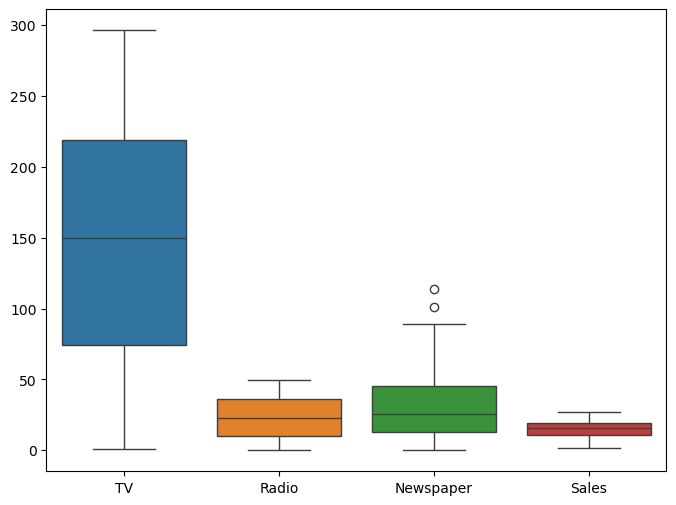

In [7]:
plt.figure(figsize=(8,6))
sns.boxplot(data=dataset)
plt.show()

<Figure size 1600x1000 with 0 Axes>

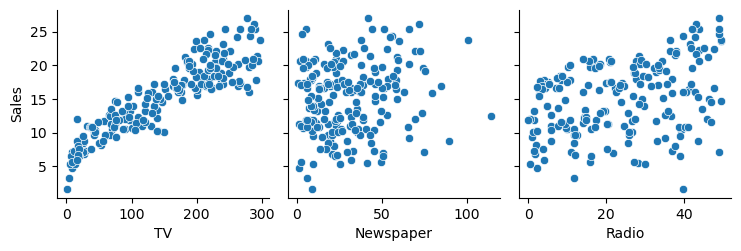

In [8]:
plt.figure(figsize=(16,10))
sns.pairplot(dataset, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales')
plt.show()

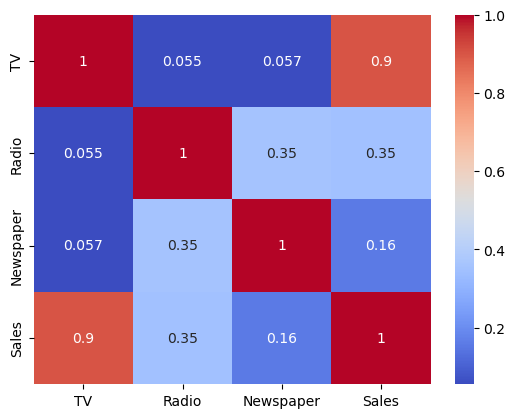

In [9]:
sns.heatmap(dataset.corr(), cmap="coolwarm", annot = True)
plt.show()

## 📊 Exploratory Data Analysis (EDA)

EDA was performed to understand the distribution of data and relationships between variables.

### Key Observations:
- TV and Radio advertising show strong positive correlation with Sales
- Newspaper has very weak correlation with Sales
- No significant outliers were observed

In [10]:
input_data = dataset.iloc[:,:-1]
output_data = dataset["Sales"]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_test,x_train,y_test,y_train = train_test_split(input_data,output_data,test_size=0.2,random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = model.predict(x_test)


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 1.2867335934388993
MSE: 3.0036983167095093
R2 Score: 0.8879190891395372


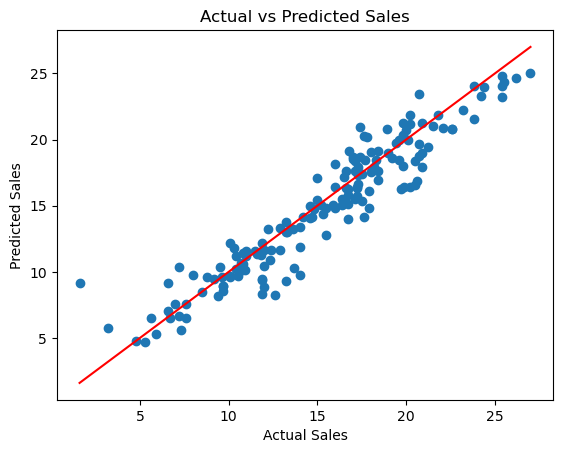

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [17]:
input_data_X = dataset.iloc[:,:-2]
output_data_Y = dataset["Sales"]

In [18]:
X_test,X_train,Y_test,Y_train = train_test_split(input_data_X,output_data_Y,test_size=0.2,random_state=42)

## 🤖 Model Building

A Linear Regression model was used to predict sales.

Steps:
- Split data into training and testing sets
- Trained the model using training data
- Made predictions on test data

In [19]:
Model = LinearRegression()
Model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
Y_pred = Model.predict(X_test)


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 1.284068547394186
MSE: 2.9956163093109778
R2 Score: 0.8882206636171635


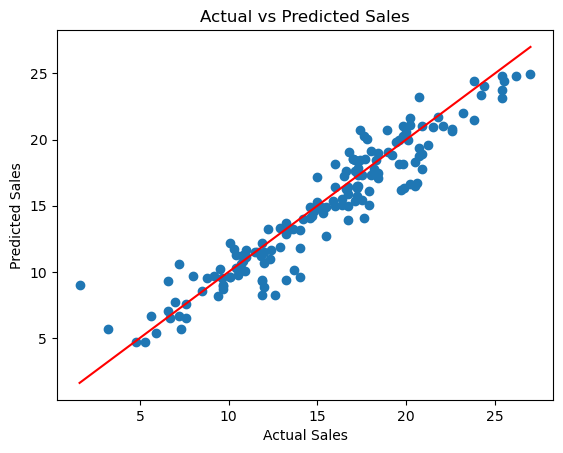

In [22]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, Y_pred)

# Perfect prediction line
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

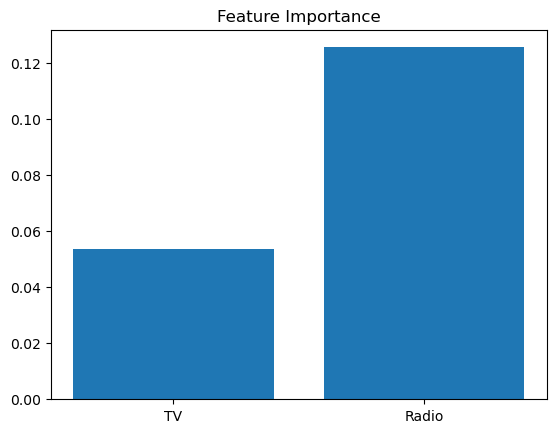

In [23]:
features = ['TV', 'Radio']
coefficients = Model.coef_

plt.bar(features, coefficients)
plt.title("Feature Importance")
plt.show()

## 🧠 Feature Selection

Based on EDA insights, Newspaper was found to have minimal impact on sales. 

Models were trained using:
- All features
- Only TV and Radio

The performance remained almost the same, indicating Newspaper is not an important feature.

In [24]:
import joblib
joblib.dump(Model, "sales_model.pkl")

['sales_model.pkl']

## 📈 Model Evaluation

The model was evaluated using the following metrics:

- **MAE (Mean Absolute Error)**: Measures average prediction error
- **MSE (Mean Squared Error)**: Penalizes large errors
- **R² Score**: Indicates how well the model explains the data

### Results:
- R² Score ≈ 0.88 (strong performance)
- MAE ≈ 1.29
- MSE ≈ 3.00

## 📊 Model Visualization

- Actual vs Predicted plot shows predictions are close to actual values
- Feature importance plot shows TV and Radio contribute most to sales

## ✅ Conclusion

- TV advertising has the highest overall impact on sales
- Radio advertising also contributes significantly
- Newspaper advertising has minimal effect
- The model performs well with an R² score of ~0.88

This model can help businesses allocate advertising budgets effectively.